In [49]:
import numpy as np
import pandas as pd

df = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['indicator', 'date'], inplace=True)

# Limit to the last 100 unique dates
latest_dates = df['date'].drop_duplicates().sort_values().tail(100)
df = df[df['date'].isin(latest_dates)]

In [50]:
# Function to extract features per indicator
def extract_time_series_features(group):
    series = group['seen'].values
    dates = group['date'].values

    indices = np.where(series == 1)[0]
    if len(indices) == 0:
        return pd.Series({
            'last_seen': len(series),
            'freq_7': 0,
            'freq_30': 0,
            'avg_gap': len(series),
            'burstiness': 0,
            'label_7': 0,
            'label_14': 0,
            'label_30': 0
        })

    last_seen = len(series) - 1 - indices[-1] # Number of days since the IP was last seen. Recent = low value. Captures recency.
    freq_7 = np.sum(series[-7:]) # Count of days seen in the last 7 days. Measures short-term activity.
    freq_30 = np.sum(series[-30:]) # Count of days seen in the last 30 days. Measures medium-term activity.
    gaps = np.diff(indices)
    avg_gap = np.mean(gaps) if len(gaps) > 0 else len(series) # Average time (in days) between two consecutive sightings. Shows periodicity.
    burstiness = (np.std(gaps) - avg_gap) / (np.std(gaps) + avg_gap) if len(gaps) > 1 else 0 # Measures how irregular or volatile the sightings are. Based on standard deviation of gaps: Ranges from -1 (very regular) to +1 (very bursty).
    label_7 = 1 if np.any(series[-7:]) else 0
    label_14 = 1 if np.any(series[-14:]) else 0
    label_30 = 1 if np.any(series[-30:]) else 0

    return pd.Series({
        'last_seen': last_seen,
        'freq_7': freq_7,
        'freq_30': freq_30,
        'avg_gap': avg_gap,
        'burstiness': burstiness,
        'label_7': label_7,
        'label_14': label_14,
        'label_30': label_30
    })

# Apply to each indicator group
features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_12660\1570248052.py:41: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
from scipy.stats import expon
import numpy as np

# Copy features into a separate DataFrame for modeling
df_pred = features_df.copy()

# Define features and labels
X = df_pred[['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']]
y_7 = df_pred['label_7']
y_14 = df_pred['label_14']
y_30 = df_pred['label_30']

# Helper functions
def train_predict(model_cls, X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([('scaler', StandardScaler()), ('clf', model_cls())])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def train_gbt(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = GradientBoostingClassifier()
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

# Logistic Regression Predictions
df_pred['logistic_7'] = train_predict(LogisticRegression, X, y_7)
df_pred['logistic_14'] = train_predict(LogisticRegression, X, y_14)
df_pred['logistic_30'] = train_predict(LogisticRegression, X, y_30)

# Gradient Boosted Tree Predictions
df_pred['gbt_7'] = train_gbt(X, y_7)
df_pred['gbt_14'] = train_gbt(X, y_14)
df_pred['gbt_30'] = train_gbt(X, y_30)

# Exponential Model (Poisson-based) P(\text{seen in } t \text{ days}) = 1 - e^{-λt}, \quad \text{where } λ = \frac{\text{freq_30}}{30}
rate = (df_pred['freq_30'] / 30).clip(lower=1e-6)
df_pred['exp_7'] = 1 - np.exp(-rate * 7)
df_pred['exp_14'] = 1 - np.exp(-rate * 14)
df_pred['exp_30'] = 1 - np.exp(-rate * 30)

# Weibull AFT Model A survival model that predicts time until next sighting.
aft_df = X.copy()
aft_df['duration'] = df_pred['avg_gap']
aft_df['event'] = y_7

aft = WeibullAFTFitter()
aft.fit(aft_df, duration_col='duration', event_col='event')

# Predict survival function at 1, 7, 14, 30 days
surv_func = aft.predict_survival_function(aft_df, times=[1, 7, 14, 30])
df_pred['weibull_today'] = 1 - surv_func.loc[1].values
df_pred['weibull_7'] = 1 - surv_func.loc[7].values
df_pred['weibull_14'] = 1 - surv_func.loc[14].values
df_pred['weibull_30'] = 1 - surv_func.loc[30].values

# Today's forecast
df_pred['exp_today'] = 1 - np.exp(-rate * 1)
df_pred['logistic_today'] = train_predict(LogisticRegression, X, y_7)
df_pred['gbt_today'] = train_gbt(X, y_7)

# Merge in actual "seen" value for today's date
latest_date = df['date'].max()
today_seen = df[df['date'] == latest_date][['indicator', 'seen']].rename(columns={'seen': 'seen_today'})
df_pred = df_pred.merge(today_seen, on='indicator', how='left')

# Final output
output = df_pred[[
    'indicator', 'seen_today', 'last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness',
    'exp_today', 'exp_7', 'exp_14', 'exp_30',
    'weibull_today', 'weibull_7', 'weibull_14', 'weibull_30',
    'logistic_today', 'logistic_7', 'logistic_14', 'logistic_30',
    'gbt_today', 'gbt_7', 'gbt_14', 'gbt_30'
]]

display(output)

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.90.61.13,0,75.0,0.0,0.0,1.000000,0.000000,9.999995e-07,0.000007,0.000014,...,0.000323,0.001810,2.164055e-07,2.164055e-07,5.830334e-08,0.000026,0.000025,0.000025,0.000030,0.000034
1,102.91.94.193,0,75.0,0.0,0.0,1.000000,0.000000,9.999995e-07,0.000007,0.000014,...,0.000323,0.001810,2.164055e-07,2.164055e-07,5.830334e-08,0.000026,0.000025,0.000025,0.000030,0.000034
2,103.108.231.67,0,28.0,0.0,1.0,100.000000,0.000000,3.278390e-02,0.208110,0.372911,...,0.000119,0.000665,6.798878e-03,6.798878e-03,1.720736e-02,0.774234,0.000025,0.000025,0.000030,0.999992
3,103.133.107.28,1,0.0,5.0,14.0,1.153846,-0.368101,3.729109e-01,0.961867,0.998546,...,1.000000,1.000000,9.999358e-01,9.999358e-01,9.989384e-01,0.999917,0.999982,0.999982,0.999986,0.999992
4,103.147.185.248,1,0.0,4.0,8.0,2.285714,-0.183197,2.340717e-01,0.845362,0.976087,...,1.000000,1.000000,9.995988e-01,9.995988e-01,9.982004e-01,0.999768,0.999982,0.999982,0.999986,0.999992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,www.3u.com,0,50.0,0.0,0.0,100.000000,0.000000,9.999995e-07,0.000007,0.000014,...,0.000006,0.000035,6.860211e-05,6.860211e-05,4.104902e-05,0.017260,0.000025,0.000025,0.000030,0.000034
560,www.deepseek.com,1,0.0,7.0,25.0,1.245902,-0.182201,5.654018e-01,0.997072,0.999991,...,1.000000,1.000000,9.999991e-01,9.999991e-01,9.994319e-01,0.999993,0.999982,0.999982,0.999986,0.999992
561,www.deepseek.com.cdn.cloudflare.net,0,1.0,5.0,23.0,1.314815,-0.156555,5.354410e-01,0.995330,0.999978,...,1.000000,1.000000,9.999497e-01,9.999497e-01,9.976964e-01,0.999985,0.999982,0.999982,0.999986,0.999992
562,www.filemail.com,0,8.0,0.0,2.0,5.333333,-0.007937,6.449301e-02,0.372911,0.606759,...,0.841771,0.999968,2.077898e-01,2.077898e-01,8.596934e-01,0.995197,0.000025,0.000025,0.999986,0.999992


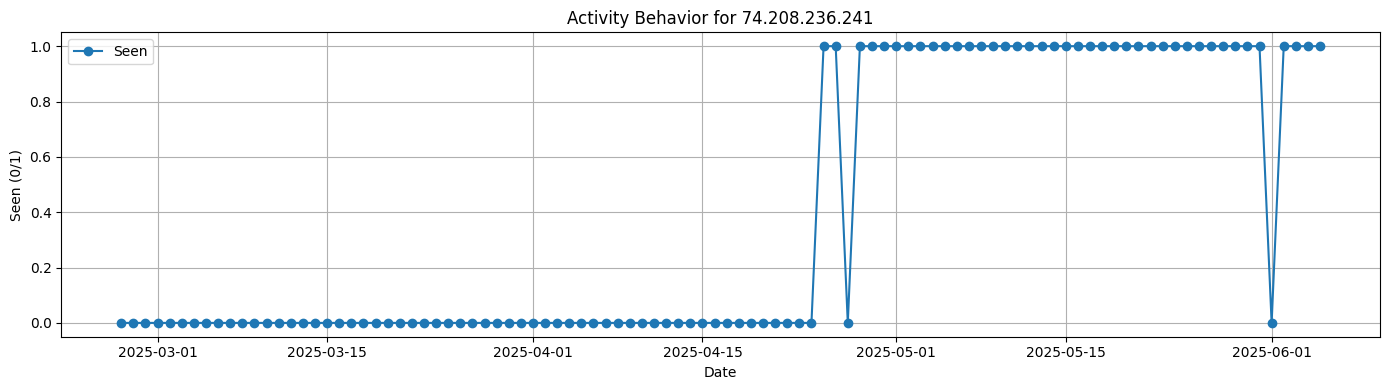

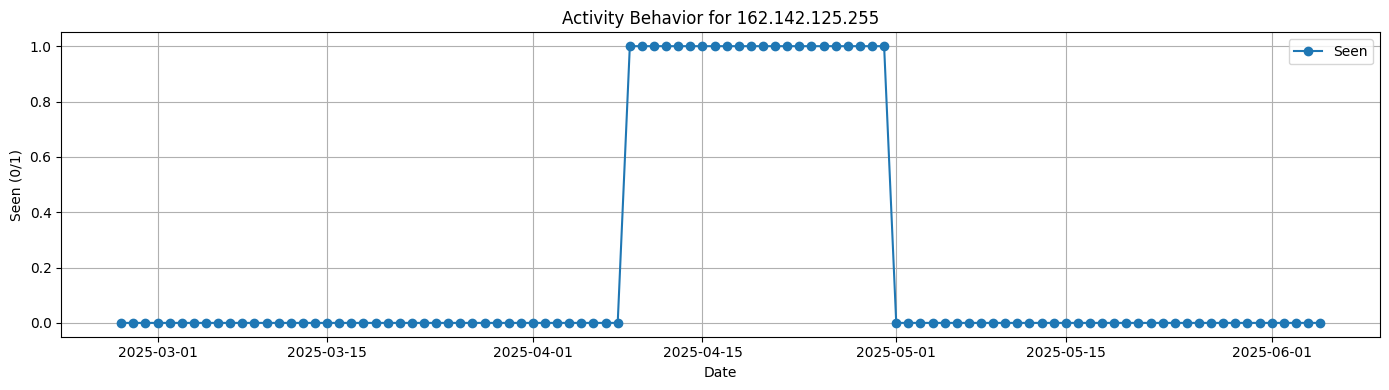

In [55]:
import matplotlib.pyplot as plt

# List of indicator IDs to plot
indicator_ids = ['74.208.236.241', '162.142.125.255']  # Add more as needed

for indicator_id in indicator_ids:
    df_plot = df[df['indicator'] == indicator_id].sort_values('date')

    plt.figure(figsize=(14, 4))
    plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
    plt.title(f'Activity Behavior for {indicator_id}')
    plt.xlabel('Date')
    plt.ylabel('Seen (0/1)')
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import expon
import numpy as np
import warnings

#  Define features and labels ---
features = ['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']
X = output[features]

#  Rule-Based Binary Labels Using last_seen ---
output['rule_today'] = output['last_seen'].apply(lambda x: 1 if x == 0 else 0)
output['rule_7d'] = output['last_seen'].apply(lambda x: 1 if x <= 6 else 0)
output['rule_14d'] = output['last_seen'].apply(lambda x: 1 if x <= 13 else 0)
output['rule_30d'] = output['last_seen'].apply(lambda x: 1 if x <= 29 else 0)

y_today = output['rule_today']
y_7 = output['rule_7d']
y_14 = output['rule_14d']
y_30 = output['rule_30d']

#  Logistic Regression Model ---
def train_logistic_model(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

output['prob_today'] = train_logistic_model(X, y_today)
output['prob_7d'] = train_logistic_model(X, y_7)
output['prob_14d'] = train_logistic_model(X, y_14)
output['prob_30d'] = train_logistic_model(X, y_30)

#  Ensemble Probabilities ---
output['ensemble_7d'] = (
    0.3 * output['prob_7d'].astype(float) +
    0.25 * output['gbt_7'] +
    0.25 * output['weibull_7'] +
    0.3 * output['exp_7']
)

output['ensemble_14d'] = (
    0.3 * output['prob_14d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25* output['weibull_14'] +
    0.3 * output['exp_14']
)

output['ensemble_30d'] = (
    0.3 * output['prob_30d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25 * output['weibull_30'] +
    0.3 * output['exp_30']
)

#  Confidence Tags ---
def classify_window(prob, freq_7, high_thresh, label):
    if prob >= high_thresh and freq_7 >= 2:
        return f"{label}: Highly likely"
    elif prob >= 0.07 and freq_7 >= 1:
        return f"{label}: Possibly active"
    else:
        return f"{label}: Low confidence"

# Compute confidence tags using raw probabilities (not formatted as strings)
output['confidence_today'] = output.apply(
    lambda row: classify_window(
        row['prob_today'],
        row['freq_7'], 0.6, 'Today'
    ), axis=1
)

output['confidence_7d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_7d'],
        row['freq_7'], 0.6, '7-Day'
    ), axis=1
)

output['confidence_14d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_14d'],
        row['freq_7'], 0.6, '14-Day'
    ), axis=1
)

output['confidence_30d'] = output.apply(
    lambda row: classify_window(
        row['ensemble_30d'],
        row['freq_7'], 0.6, '30-Day'
    ), axis=1
)

#  Format Percentages ---
for col in ['prob_7d', 'prob_14d', 'prob_30d', 'ensemble_7d', 'ensemble_14d', 'ensemble_30d']:
    output[col] = np.clip(output[col].astype(float) * 100, 0, 100).round(2).astype(str) + '%'

#  Format Today prob ---
output['prob_today'] = np.clip(output['prob_today'].astype(float) * 100, 0, 100).round(2).astype(str) + '%'

#  Final Output ---
# Suppress SettingWithCopyWarning for display purposes (optional, not recommended for production)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
production_output = output[[
    'indicator', 'seen_today', 'freq_7', 'freq_30',
    'prob_today', 'confidence_today',
    'ensemble_7d', 'confidence_7d',
    'ensemble_14d', 'confidence_14d',
    'ensemble_30d', 'confidence_30d'
]].copy()

# --- Rename for display ---
production_output.rename(columns={
    'indicator': 'Indicator',
    'seen_today': 'Observed Today',
    'freq_7': 'Frequency (7d)',
    'freq_30': 'Frequency (30d)',
    'prob_today': 'Probability: Today',
    'confidence_today': 'Confidence: Today',
    'ensemble_7d': 'Probability: 7-Day',
    'confidence_7d': 'Confidence: 7-Day',
    'ensemble_14d': 'Probability: 14-Day',
    'confidence_14d': 'Confidence: 14-Day',
    'ensemble_30d': 'Probability: 30-Day',
    'confidence_30d': 'Confidence: 30-Day'
}, inplace=True)

display(production_output)



,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
0,102.90.61.13,0,0.0,0.0,0.0%,Today: Low confidence,0.0%,7-Day: Low confidence,0.01%,14-Day: Low confidence,0.05%,30-Day: Low confidence
1,102.91.94.193,0,0.0,0.0,0.0%,Today: Low confidence,0.0%,7-Day: Low confidence,0.01%,14-Day: Low confidence,0.05%,30-Day: Low confidence
2,103.108.231.67,0,0.0,1.0,0.05%,Today: Low confidence,6.45%,7-Day: Low confidence,11.71%,14-Day: Low confidence,42.21%,30-Day: Low confidence
3,103.133.107.28,1,5.0,14.0,72.82%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
4,103.147.185.248,1,4.0,8.0,57.51%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
...,...,...,...,...,...,...,...,...,...,...,...,...
559,www.3u.com,0,0.0,0.0,0.0%,Today: Low confidence,0.0%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.52%,30-Day: Low confidence
560,www.deepseek.com,1,7.0,25.0,83.62%,Today: Highly likely,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
561,www.deepseek.com.cdn.cloudflare.net,0,5.0,23.0,47.34%,Today: Possibly active,100.0%,7-Day: Highly likely,100.0%,14-Day: Highly likely,100.0%,30-Day: Highly likely
562,www.filemail.com,0,0.0,2.0,1.21%,Today: Low confidence,25.39%,7-Day: Low confidence,90.04%,14-Day: Low confidence,100.0%,30-Day: Low confidence


In [ ]:
#production_output.to_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\production_output.csv', index=False)